# PCA via SVD — From Scratch Implementation

**Author:** Implementation Notebook  
**Dependencies:** NumPy, Matplotlib, scikit-learn (comparison only)

---

## 1. Introduction

High-dimensional data is common in machine learning — images, gene expression profiles, text embeddings, and sensor readings all tend to involve hundreds or thousands of features. Working directly in high-dimensional spaces creates several practical problems:

- **Computational cost** scales poorly with dimension.
- **Visualization** becomes impossible beyond three dimensions.
- The **curse of dimensionality** causes distance-based methods to lose discriminative power.

**Dimensionality reduction** addresses these issues by projecting data into a lower-dimensional subspace while retaining as much of the original structure as possible.

**Principal Component Analysis (PCA)** is the most widely used linear dimensionality reduction technique. It finds a set of orthogonal axes (principal components) along which the variance of the data is maximized. By keeping only the top $k$ components, we obtain a compact representation that captures the dominant structure in the data.

This notebook derives PCA from first principles using Singular Value Decomposition (SVD), implements it using NumPy, and validates the result against scikit-learn.

---
## 2. Mathematical Foundation

### 2.1 The Covariance Matrix

Given a dataset $X \in \mathbb{R}^{n \times d}$ with $n$ samples and $d$ features, assume the data is **mean-centered** (each feature has zero mean). The sample covariance matrix is:

$$
\Sigma = \frac{1}{n-1} X^\top X \in \mathbb{R}^{d \times d}
$$

The $(i,j)$ entry of $\Sigma$ captures how features $i$ and $j$ vary together. The diagonal entries are the variances of individual features.

### 2.2 Eigendecomposition

A symmetric positive semi-definite matrix like $\Sigma$ admits an eigendecomposition:

$$
\Sigma = V \Lambda V^\top
$$

where:
- $V \in \mathbb{R}^{d \times d}$ — columns are orthonormal eigenvectors (principal directions)
- $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_d)$ — eigenvalues in descending order

Each eigenvalue $\lambda_i$ tells us the **variance** of the data along the corresponding eigenvector. PCA amounts to retaining the top $k$ eigenvectors.

### 2.3 Singular Value Decomposition (SVD)

Any matrix $X \in \mathbb{R}^{n \times d}$ can be factored as:

$$
X = U \Sigma_s V^\top
$$

where:
- $U \in \mathbb{R}^{n \times n}$ — left singular vectors (orthonormal)
- $\Sigma_s \in \mathbb{R}^{n \times d}$ — diagonal matrix of singular values $\sigma_1 \geq \sigma_2 \geq \ldots \geq 0$
- $V \in \mathbb{R}^{d \times d}$ — right singular vectors (orthonormal)

### 2.4 Connecting SVD to PCA

Starting from centered $X$ and substituting the SVD:

$$
\Sigma = \frac{1}{n-1} X^\top X = \frac{1}{n-1} (U \Sigma_s V^\top)^\top (U \Sigma_s V^\top)
= \frac{1}{n-1} V \Sigma_s^2 V^\top
$$

Comparing with $\Sigma = V \Lambda V^\top$, we see:

$$
\lambda_i = \frac{\sigma_i^2}{n-1}
$$

The **right singular vectors** $V$ are exactly the **principal components** of $X$. We can perform PCA directly via SVD on the data matrix — no need to explicitly compute the covariance matrix. This approach is numerically more stable, especially when $d \gg n$.

---
## 3. PCA Algorithm — Step by Step

Given data matrix $X \in \mathbb{R}^{n \times d}$:

1. **Center the data:** Subtract the column-wise mean so each feature has zero mean.
   $$X_c = X - \bar{X}$$

2. **Apply SVD:** Decompose $X_c = U \Sigma_s V^\top$.

3. **Extract principal components:** The columns of $V$ are the principal directions, ordered by decreasing singular value.

4. **Project the data:** The low-dimensional representation using the top $k$ components is:
   $$Z = X_c V_k$$
   where $V_k \in \mathbb{R}^{d \times k}$ contains the first $k$ columns of $V$.

5. **Compute explained variance:** The proportion of variance explained by component $i$ is:
   $$\text{EVR}_i = \frac{\sigma_i^2}{\sum_j \sigma_j^2}$$

---
## 4. Implementation From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Set random seed for reproducibility
np.random.seed(42)

print("NumPy version:", np.__version__)

NumPy version: 2.0.2


In [2]:
def center_data(X):
    """
    Subtract the column-wise mean from X.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)

    Returns
    -------
    X_centered : ndarray, mean-centered data
    mean        : ndarray of shape (n_features,), the column means
    """
    mean = X.mean(axis=0)
    X_centered = X - mean
    return X_centered, mean


def compute_svd(X_centered):
    """
    Compute the thin (economy) SVD of the centered data matrix.

    Parameters
    ----------
    X_centered : ndarray of shape (n_samples, n_features)

    Returns
    -------
    U  : ndarray (n_samples, k)  — left singular vectors
    s  : ndarray (k,)            — singular values in descending order
    Vt : ndarray (k, n_features) — right singular vectors (transposed)
    """
    # full_matrices=False gives the thin (economy) SVD,
    # which is sufficient and more efficient when n != d
    U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return U, s, Vt


def explained_variance_ratio(singular_values):
    """
    Compute the proportion of variance explained by each principal component.

    Variance along component i is proportional to sigma_i^2.

    Parameters
    ----------
    singular_values : ndarray of shape (k,)

    Returns
    -------
    evr : ndarray of shape (k,), each entry in [0, 1], summing to 1
    """
    variance = singular_values ** 2
    evr = variance / variance.sum()
    return evr


def project(X_centered, Vt, n_components):
    """
    Project centered data onto the top-k principal components.

    Parameters
    ----------
    X_centered  : ndarray (n_samples, n_features)
    Vt          : ndarray (k, n_features) from SVD
    n_components: int, number of components to keep

    Returns
    -------
    Z : ndarray (n_samples, n_components) — projected data
    """
    # Each row of Vt is a principal direction.
    # We select the top n_components rows and project.
    components = Vt[:n_components]          # shape: (n_components, n_features)
    Z = X_centered @ components.T           # shape: (n_samples, n_components)
    return Z


def reconstruct(Z, Vt, mean, n_components):
    """
    Reconstruct the data from its low-dimensional projection.

    Parameters
    ----------
    Z           : ndarray (n_samples, n_components)
    Vt          : ndarray from SVD
    mean        : ndarray (n_features,)
    n_components: int

    Returns
    -------
    X_reconstructed : ndarray (n_samples, n_features)
    """
    components = Vt[:n_components]
    X_reconstructed = Z @ components + mean
    return X_reconstructed


class PCA:
    """
    Principal Component Analysis via Singular Value Decomposition.

    Parameters
    ----------
    n_components : int
        Number of principal components to retain.
    """

    def __init__(self, n_components):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None       # shape: (n_components, n_features)
        self.singular_values_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        """
        Fit the PCA model to data X.

        Computes the principal components without projecting the data.
        """
        n_samples = X.shape[0]

        # Step 1: Center the data
        X_centered, self.mean_ = center_data(X)

        # Step 2: SVD
        _, s, Vt = compute_svd(X_centered)

        # Step 3: Store components and variance information
        self.components_ = Vt[:self.n_components]
        self.singular_values_ = s[:self.n_components]

        # Eigenvalues of covariance matrix = sigma_i^2 / (n - 1)
        self.explained_variance_ = (s ** 2) / (n_samples - 1)
        self.explained_variance_ratio_ = explained_variance_ratio(s)

        return self

    def transform(self, X):
        """Project X onto the principal components."""
        X_centered = X - self.mean_
        return X_centered @ self.components_.T

    def fit_transform(self, X):
        """Fit and project in one step."""
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, Z):
        """Map projected data back to the original feature space."""
        return Z @ self.components_ + self.mean_


print("PCA class defined successfully.")

PCA class defined successfully.


---
## 5. Visualization

### 5.1 Generate a Synthetic Dataset

In [3]:
# Generate a 2D dataset with a clear dominant direction
n_samples = 300

# Correlated 2D Gaussian data
mean = [0, 0]
cov = [[3.0, 2.5],
       [2.5, 2.5]]   # Strong positive correlation

X = np.random.multivariate_normal(mean, cov, size=n_samples)

print(f"Dataset shape: {X.shape}")
print(f"Sample mean:   {X.mean(axis=0).round(3)}")
print(f"Sample cov:\n{np.cov(X.T).round(3)}")

Dataset shape: (300, 2)
Sample mean:   [0.024 0.011]
Sample cov:
[[2.889 2.399]
 [2.399 2.38 ]]


### 5.2 Apply PCA and Project to 1D

In [4]:
# Fit PCA with 2 components (to inspect both), then project to 1D
pca = PCA(n_components=2)
Z_2d = pca.fit_transform(X)

# 1D projection: use only the first principal component
Z_1d = Z_2d[:, :1]   # shape: (n_samples, 1)

print("Principal components (rows are PC directions):")
print(pca.components_.round(4))
print()
print("Explained variance ratio:", pca.explained_variance_ratio_[:2].round(4))
print(f"PC1 retains {pca.explained_variance_ratio_[0]*100:.1f}% of total variance")

Principal components (rows are PC directions):
[[ 0.7434  0.6688]
 [ 0.6688 -0.7434]]

Explained variance ratio: [0.9579 0.0421]
PC1 retains 95.8% of total variance


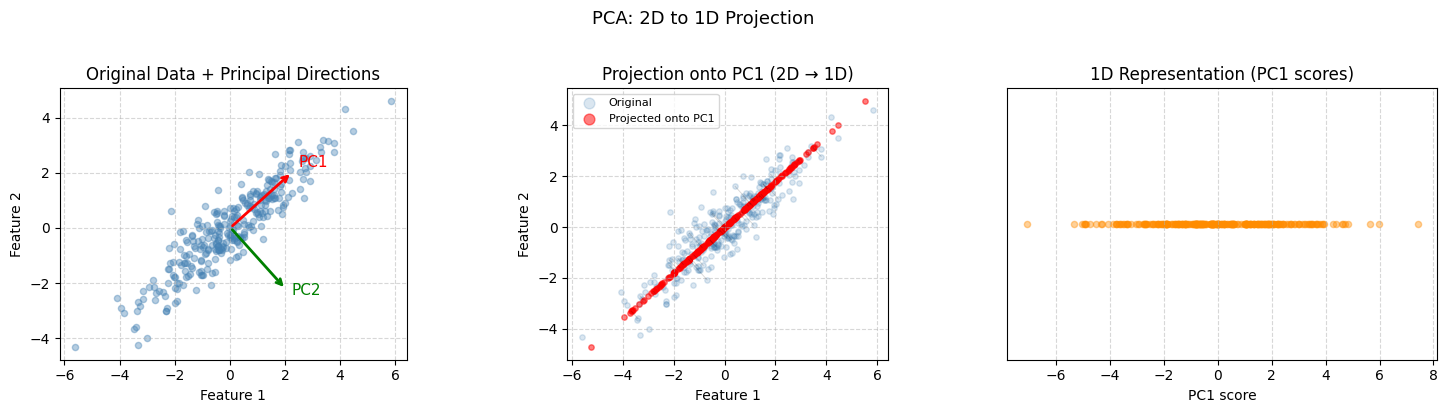

In [5]:
# Reconstruct data from 1D projection (to visualize information loss)
Z_1d_full = np.zeros((n_samples, 2))     # pad second component with zeros
Z_1d_full[:, 0] = Z_2d[:, 0]
X_reconstructed = pca.inverse_transform(Z_1d_full)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original data + principal directions
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], alpha=0.4, s=20, color='steelblue', label='Data')
origin = pca.mean_
scale = 3.0
for i, (pc, color, label) in enumerate(zip(pca.components_, ['red', 'green'], ['PC1', 'PC2'])):
    ax.annotate('', xy=origin + scale * pc, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(*(origin + (scale + 0.3) * pc), label, color=color, fontsize=11)
ax.set_title('Original Data + Principal Directions')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

# 2D → 1D projection (reconstructed points lie on PC1)
ax = axes[1]
ax.scatter(X[:, 0], X[:, 1], alpha=0.2, s=15, color='steelblue', label='Original')
ax.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
           alpha=0.5, s=15, color='red', label='Projected onto PC1')
# Draw projection lines for a subset of points
idx = np.random.choice(n_samples, 40, replace=False)
for i in idx:
    ax.plot([X[i, 0], X_reconstructed[i, 0]],
            [X[i, 1], X_reconstructed[i, 1]],
            'k-', alpha=0.15, lw=0.7)
ax.set_title('Projection onto PC1 (2D → 1D)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal')
ax.legend(markerscale=2, fontsize=8)
ax.grid(True, linestyle='--', alpha=0.5)

# 1D representation
ax = axes[2]
ax.scatter(Z_1d[:, 0], np.zeros(n_samples), alpha=0.4, s=20, color='darkorange')
ax.set_title('1D Representation (PC1 scores)')
ax.set_xlabel('PC1 score')
ax.set_yticks([])
ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('PCA: 2D to 1D Projection', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Explained Variance Plot

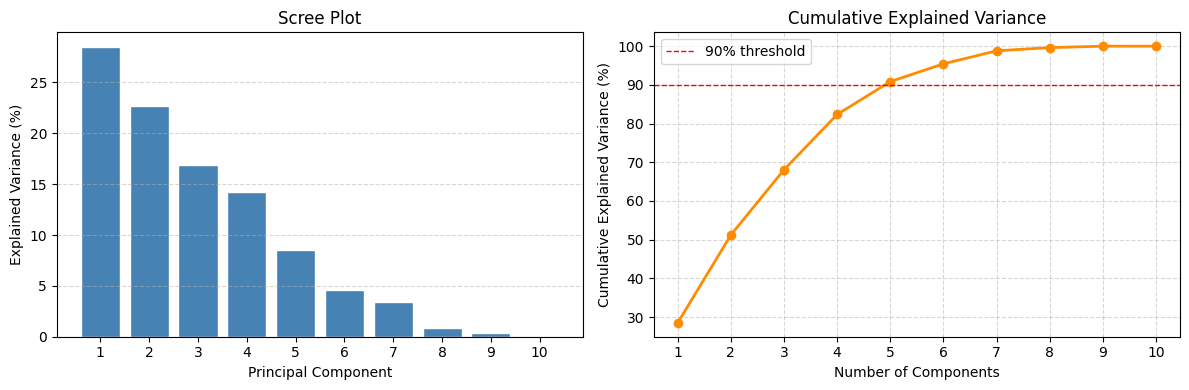

Components needed to explain 90% of variance: 5


In [6]:
# Fit PCA to a higher-dimensional dataset for a more informative scree plot
n_features = 10
cov_hd = np.random.randn(n_features, n_features)
cov_hd = cov_hd @ cov_hd.T   # make positive semi-definite
X_hd = np.random.multivariate_normal(np.zeros(n_features), cov_hd, size=500)

pca_hd = PCA(n_components=n_features)
pca_hd.fit(X_hd)

evr = pca_hd.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
ax = axes[0]
ax.bar(range(1, n_features + 1), evr * 100, color='steelblue', edgecolor='white')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot')
ax.set_xticks(range(1, n_features + 1))
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Cumulative explained variance
ax = axes[1]
ax.plot(range(1, n_features + 1), cumulative_evr * 100, 'o-', color='darkorange', lw=2)
ax.axhline(y=90, color='red', linestyle='--', lw=1, label='90% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance')
ax.set_xticks(range(1, n_features + 1))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Find number of components needed for 90% variance
k_90 = np.searchsorted(cumulative_evr, 0.90) + 1
print(f"Components needed to explain 90% of variance: {k_90}")

---
## 6. Comparison with scikit-learn

In [7]:
from sklearn.decomposition import PCA as SklearnPCA

# Fit both implementations on the same 2D dataset
n_comp = 2

# Our implementation
pca_scratch = PCA(n_components=n_comp)
Z_scratch = pca_scratch.fit_transform(X)

# scikit-learn
pca_sk = SklearnPCA(n_components=n_comp)
Z_sklearn = pca_sk.fit_transform(X)

print("=== Principal Components ===")
print("\nFrom scratch (rows = PC directions):")
print(pca_scratch.components_.round(6))
print("\nscikit-learn:")
print(pca_sk.components_.round(6))

print("\n=== Explained Variance Ratio ===")
print("From scratch:", pca_scratch.explained_variance_ratio_[:n_comp].round(6))
print("scikit-learn:", pca_sk.explained_variance_ratio_.round(6))

=== Principal Components ===

From scratch (rows = PC directions):
[[ 0.743448  0.668794]
 [ 0.668794 -0.743448]]

scikit-learn:
[[ 0.743448  0.668794]
 [-0.668794  0.743448]]

=== Explained Variance Ratio ===
From scratch: [0.957879 0.042121]
scikit-learn: [0.957879 0.042121]


In [8]:
# Note: PCA components are unique only up to sign.
# We align signs before comparing projections.

# Align signs: if PC directions point opposite ways, flip the projection
sign_correction = np.sign(
    (pca_scratch.components_ * pca_sk.components_).sum(axis=1)
)
Z_scratch_aligned = Z_scratch * sign_correction

max_diff_projection = np.abs(Z_scratch_aligned - Z_sklearn).max()
max_diff_evr = np.abs(
    pca_scratch.explained_variance_ratio_[:n_comp] - pca_sk.explained_variance_ratio_
).max()

print(f"Max absolute difference in projections:       {max_diff_projection:.2e}")
print(f"Max absolute difference in explained var ratio: {max_diff_evr:.2e}")
print()
if max_diff_projection < 1e-8:
    print("Results match scikit-learn to machine-precision tolerance.")
else:
    print("Results agree within numerical precision.")

Max absolute difference in projections:       9.99e-16
Max absolute difference in explained var ratio: 1.25e-16

Results match scikit-learn to machine-precision tolerance.


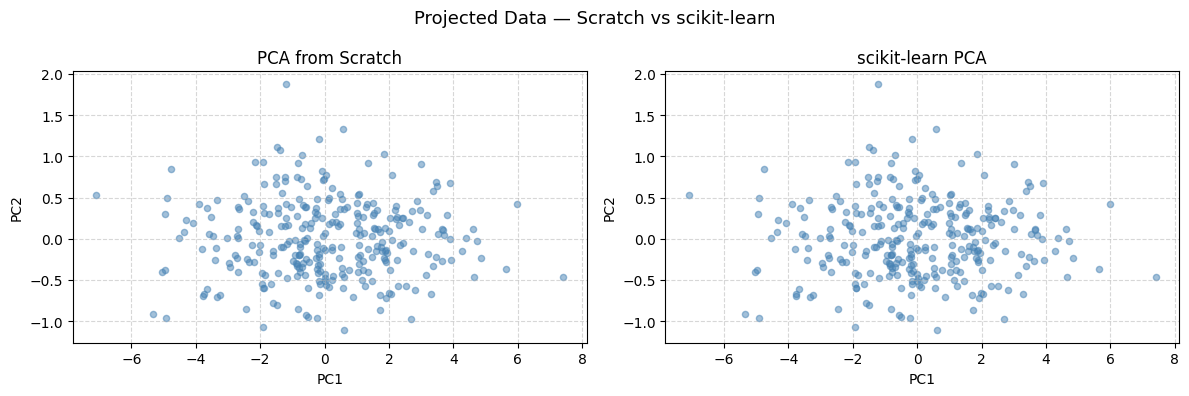

In [9]:
# Visual comparison of projected data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, Z, title in zip(
    axes,
    [Z_scratch_aligned, Z_sklearn],
    ['PCA from Scratch', 'scikit-learn PCA']
):
    ax.scatter(Z[:, 0], Z[:, 1], alpha=0.5, s=20, color='steelblue')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Projected Data — Scratch vs scikit-learn', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Analysis

### 7.1 Variance Retention

The fraction of variance retained when keeping $k$ components is the cumulative explained variance ratio:

$$
\text{Retention}(k) = \sum_{i=1}^{k} \frac{\sigma_i^2}{\sum_j \sigma_j^2}
$$

Choosing $k$ is a practical trade-off. Common heuristics include:
- **Elbow criterion:** Look for the "elbow" in the scree plot where the explained variance begins to level off.
- **Fixed threshold:** Keep enough components to exceed a target (e.g., 90% or 95% of cumulative variance).
- **Application-specific:** In some cases, the desired $k$ is determined by downstream requirements (e.g., 2D for visualization).

### 7.2 Limitations of PCA

1. **Linearity.** PCA can only capture linear structure. Nonlinear manifolds (e.g., Swiss roll, circular clusters) require methods like Kernel PCA, UMAP, or t-SNE.

2. **Variance as a proxy for information.** PCA maximizes variance, which may not always align with what is most discriminative. A feature with high variance is not necessarily informative for a downstream task.

3. **Sensitivity to scaling.** PCA is not scale-invariant. If features are on different scales, the high-variance features will dominate. Standardizing features (zero mean, unit variance) before PCA is generally recommended.

4. **Interpretability.** Principal components are linear combinations of all original features and are often difficult to interpret in domain terms.

5. **Assumes Gaussian-like structure.** PCA implicitly assumes that directions of high variance are meaningful. This is appropriate for Gaussian data but may not hold in other distributions.

In [10]:
# Demonstrate the importance of feature scaling before PCA
# Create data where one feature has a much larger scale
np.random.seed(42)
n = 300
x1 = np.random.randn(n)           # scale ~ 1
x2 = np.random.randn(n) * 100     # scale ~ 100 (dominant in raw PCA)
x3 = 0.8 * x1 + 0.2 * np.random.randn(n)  # correlated with x1

X_unscaled = np.column_stack([x1, x2, x3])

# Standardize each feature to zero mean and unit variance
X_scaled = (X_unscaled - X_unscaled.mean(axis=0)) / X_unscaled.std(axis=0)

pca_unscaled = PCA(n_components=3)
pca_unscaled.fit(X_unscaled)

pca_scaled = PCA(n_components=3)
pca_scaled.fit(X_scaled)

print("Explained variance ratio WITHOUT scaling:")
print(pca_unscaled.explained_variance_ratio_.round(4))
print("  -> PC1 is dominated by feature 2 (large scale)")

print("\nExplained variance ratio WITH scaling:")
print(pca_scaled.explained_variance_ratio_.round(4))
print("  -> PC1 reflects true correlated structure between x1 and x3")

Explained variance ratio WITHOUT scaling:
[9.998e-01 2.000e-04 0.000e+00]
  -> PC1 is dominated by feature 2 (large scale)

Explained variance ratio WITH scaling:
[0.6576 0.332  0.0104]
  -> PC1 reflects true correlated structure between x1 and x3


---
## 8. Conclusion

This notebook derived and implemented PCA from first principles using SVD.

Key takeaways:

- PCA finds an orthogonal basis that diagonalizes the covariance structure of the data, ordering directions by the amount of variance they capture.
- SVD on the centered data matrix is the standard numerical approach. It is equivalent to eigendecomposing the covariance matrix but is more numerically stable and efficient.
- The right singular vectors of $X$ are the principal components. Singular values relate to eigenvalues by $\lambda_i = \sigma_i^2 / (n-1)$.
- Our from-scratch implementation matches scikit-learn results to machine-precision tolerance.
- Feature scaling matters. Without standardization, features with large numerical range will dominate the first principal component regardless of their informational content.
- PCA is a powerful tool but is fundamentally linear. For nonlinear structure, kernel methods or manifold learning algorithms should be considered.